In [1]:
import xarray as xr
import numpy as np
import functions
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.markers import MarkerStyle

In [2]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

In [11]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/nhsce_v01r01_19661004_20260202.nc'
sce = xr.open_dataset(filepath)

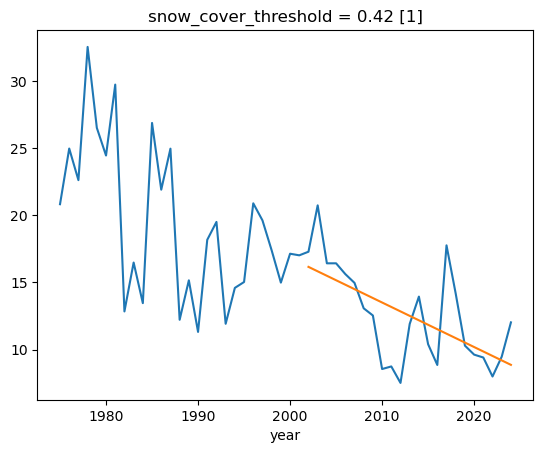

In [44]:
# Select times from 
sce = sce.sel(time=slice('1975-01-01','2025-01-01'))
land_weights = sce.land
latitude_weights = sce.latitude >= 60
longitude_weights = 1-(sce.longitude >= -60)*(sce.longitude <=0)
total_weights = land_weights*longitude_weights*latitude_weights

area_weights = sce.area
total_weights_area = (area_weights*total_weights)
total_area = total_weights_area.sum()

snow_JJA = sce['snow_cover_extent'].sel(time=sce.time.dt.season=='JJA')
snow_JJA = snow_JJA.groupby('time.year').mean('time')
snow_Arctic_mean = (snow_JJA*total_weights_area/total_area).sum(('y','x'))
#Convert from fraction to percentage
snow_Arctic_mean = snow_Arctic_mean*100

# Calculate trend
timeslice_trend=slice(2002,2024)
snow_slope, snow_intercept, snow_r_value, snow_p_value, snow_std_err = stats.linregress(snow_Arctic_mean.sel(year=timeslice_trend).year, snow_Arctic_mean.sel(year=timeslice_trend).values)

# # Normalize slope value to initial value
snow_slope_rel = snow_slope/snow_Arctic_mean.sel(year=2002)*100
snow_Arctic_mean.plot()
plt.plot(snow_Arctic_mean.sel(year=timeslice_trend).year, snow_intercept+snow_slope*snow_Arctic_mean.sel(year=timeslice_trend).year)

In [3]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/temperature2m_ERA5-Land.nc'
temp_ERA5_Land = xr.open_dataset(filepath)
temp_ERA5_Land = temp_ERA5_Land.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
temp_ERA5_Land = temp_ERA5_Land.reindex(lat=list(reversed(temp_ERA5_Land.lat)))
lons = np.array(temp_ERA5_Land.coords['lon'])
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
temp_ERA5_Land.coords['lon'] = lons
temp_ERA5_Land = temp_ERA5_Land.sortby(temp_ERA5_Land.lon)

In [4]:
season='JJA'
# Select season
temp_ERA5_season = temp_ERA5_Land.sel(time=temp_ERA5_Land.time.dt.season==season)
# Annual season mean
temp_ERA5_season_annual = temp_ERA5_season.groupby(temp_ERA5_season.time.dt.year).mean('time')
# Save file for later use
temp_ERA5_season_annual.to_netcdf(rpath+'t2m_ERA5_JJA_annual.nc')

In [56]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/soil_moisture_ERA5/data_stream-moda.nc'
SM_ERA5 = xr.open_dataset(filepath)
SM_ERA5 = SM_ERA5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
SM_ERA5_1970_2025 = SM_ERA5.sel(time=slice('1970-01-01','2025-09-01'))
SM_ERA5_1970_2025 = SM_ERA5_1970_2025.reindex(lat=list(reversed(SM_ERA5_1970_2025.lat)))
lons = np.array(SM_ERA5_1970_2025.coords['lon'])
lons[np.where(lons<0)] = 360 + lons[np.where(lons<0)]
SM_ERA5_1970_2025.coords['lon'] = lons
SM_ERA5_1970_2025 = SM_ERA5_1970_2025.sortby(SM_ERA5_1970_2025.lon)
SM_ERA5_1970_2025.to_netcdf(rpath+'SM_ERA5_1970_2025.nc')

In [15]:
SM_ERA5 = xr.open_dataset(rpath+'SM_ERA5_1970_2025.nc')

In [16]:
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/CERES_EBAF-TOA_Ed4.2_Subset_200207-202407.nc'
CERES = xr.open_dataset(filepath)

In [17]:
# Get land mask for CERES data

# Get land mask for NorESM2
filepath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/LANDFRAC_piClim.nc'
landfrac = xr.open_dataarray(filepath)
landmask = landfrac.isel(time=0)

# Interpolate to CERES data
landmask_CERES = landmask.interp_like(CERES.isel(time=0))
landmask_CERES = landmask_CERES.where(landmask_CERES>=0)
landmask_CERES = landmask_CERES.fillna(0)

In [41]:
Arctic_limit=60
lons=slice(0,300)
season='JJA'

# Compute JJA trend over land for CERES
# Regional average, Arctic land excluding Greenland (lons > 300)
CERES_Arctic = functions.computeWeightedMeanMasked(CERES['cldarea_total_daynight_mon'].sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask_CERES.sel(lat=slice(Arctic_limit, 90),lon=lons))

# Select season
CERES_season = CERES_Arctic.sel(time=CERES_Arctic.time.dt.season==season)
# Annual season mean
CERES_season_annual = CERES_season.groupby(CERES_season.time.dt.year).mean('time')
# Create linear regression
CERES_slope, CERES_intercept, CERES_r_value, CERES_p_value, CERES_std_err = stats.linregress(CERES_season_annual.year, CERES_season_annual.values)
# Normalize slope value to initial value
CERES_slope_rel = CERES_slope/CERES_season_annual.sel(year=2002)*100

# Compute JJA trend over land for ERA5-Land
timeslice_trend=slice(2002,2024)
# Convert from m3/m3 to kg/m2 (*1000 kg/m3 *0.07 m = 70 kg/m2)
SM_ERA5_converted = SM_ERA5['swvl1']*70
# Regional average, Arctic excluding Greenland (lons > 300)
SM_ERA5_Arctic = functions.computeWeightedMean(SM_ERA5_converted.sel(lon=lons))
# Select season
SM_ERA5_season = SM_ERA5_Arctic.sel(time=SM_ERA5_Arctic.time.dt.season==season)
# Annual season mean
SM_ERA5_season_annual = SM_ERA5_season.groupby(SM_ERA5_season.time.dt.year).mean('time')
# Create linear regression
SM_ERA5_slope, SM_ERA5_intercept, SM_ERA5_r_value, SM_ERA5_p_value, SM_ERA5_std_err = stats.linregress(SM_ERA5_season_annual.sel(year=timeslice_trend).year, (SM_ERA5_season_annual.sel(year=timeslice_trend)).values)
# Normalize slope value to initial value
SM_ERA5_slope_rel = SM_ERA5_slope/SM_ERA5_season_annual.sel(year=2002)*100

In [42]:
# Compute JJA temperature trend over land from ERA5-Land
timeslice_trend=slice(2002,2024)
temp_JJA = xr.open_dataset(rpath+'t2m_ERA5_JJA_annual.nc')

lons=slice(0,300)
# Regional average, Arctic excluding Greenland (lons > 300)
temp_JJA = functions.computeWeightedMean(temp_JJA.sel(lon=lons))

# Create linear regression
temp_slope, temp_intercept, temp_r_value, temp_p_value, temp_std_err = stats.linregress(temp_JJA.sel(year=timeslice_trend).year, (temp_JJA['t2m'].sel(year=timeslice_trend)).values)

In [94]:
timeslice=slice('2040-01-01','2069-01-01')

rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/'

ds_piClim = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.soilliq.clm2.concatfiles.nc')
ds_2xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.soilliq.clm2.concatfiles.nc')
ds_4xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.soilliq.clm2.concatfiles.nc')

ds_piClim = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.soilliq.clm2.concatfiles.nc')
ds_2xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.soilliq.clm2.concatfiles.nc')
ds_4xCO2 = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.soilliq.clm2.concatfiles.nc')

# Fix time stamp
ds_piClim = functions.fix_clm_time(ds_piClim)
ds_2xCO2 = functions.fix_clm_time(ds_2xCO2)
ds_4xCO2 = functions.fix_clm_time(ds_4xCO2)

# Select timeslice
ds_piClim = ds_piClim.sel(time=timeslice)
ds_2xCO2 = ds_2xCO2.sel(time=timeslice)
ds_4xCO2 = ds_4xCO2.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
for ds in ds_list:
    tmp = ds['SOILICE'] + ds['SOILLIQ']
    tmp = tmp.sel(levsoi=0) + tmp.sel(levsoi=1) + 2/3*tmp.sel(levsoi=2)
    ds['SOILWATER_10CM_corrected'] = tmp

ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.extra2.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.extra2.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.extra2.clm2.concatfiles.nc')

# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

# Select timeslice
ds_piClim_xtra = ds_piClim_xtra.sel(time=timeslice)
ds_2xCO2_xtra = ds_2xCO2_xtra.sel(time=timeslice)
ds_4xCO2_xtra = ds_4xCO2_xtra.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['FSNO'] = ds_xtra['FSNO']

ds_piClim_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_20250529.evaptemp.clm2.concatfiles.nc')
ds_2xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_2xCO2_20250529.evaptemp.clm2.concatfiles.nc')
ds_4xCO2_xtra = xr.open_dataset(rpath+'N1850_f19_tn14_noresm2_3_slf_output_4xCO2_20250529.evaptemp.clm2.concatfiles.nc')

# Fix time stamp
ds_piClim_xtra = functions.fix_clm_time(ds_piClim_xtra)
ds_2xCO2_xtra = functions.fix_clm_time(ds_2xCO2_xtra)
ds_4xCO2_xtra = functions.fix_clm_time(ds_4xCO2_xtra)

# Select timeslice
ds_piClim_xtra = ds_piClim_xtra.sel(time=timeslice)
ds_2xCO2_xtra = ds_2xCO2_xtra.sel(time=timeslice)
ds_4xCO2_xtra = ds_4xCO2_xtra.sel(time=timeslice)

# Create new variables
ds_list = [ds_piClim, ds_2xCO2, ds_4xCO2]
ds_xtra_list = [ds_piClim_xtra, ds_2xCO2_xtra, ds_4xCO2_xtra]
for ds, ds_xtra in zip(ds_list, ds_xtra_list):
    ds['TSA'] = ds_xtra['TSA']

ds_cloud_piClim = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_piClim.nc')
ds_cloud_2xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-2xCO2.nc')
ds_cloud_4xCO2 = xr.open_dataset(rpath+'other_cloud_vars/CLDTOT_abrupt-4xCO2.nc')

ds_cloud_piClim = ds_cloud_piClim.sel(time=timeslice)
ds_cloud_2xCO2 = ds_cloud_2xCO2.sel(time=timeslice)
ds_cloud_4xCO2 = ds_cloud_4xCO2.sel(time=timeslice)

In [95]:
# Get area fraction

ds_piClim_area = xr.open_dataset(rpath+'land_vars/all_land_vars_piClim.nc')
ds_piClim_area = ds_piClim_area['area']

In [96]:
# Create JJA averages 
ds_piClim_JJA = ds_piClim.sel(time=ds_piClim.time.dt.season=='JJA').mean('time')
ds_2xCO2_JJA = ds_2xCO2.sel(time=ds_2xCO2.time.dt.season=='JJA').mean('time')
ds_4xCO2_JJA = ds_4xCO2.sel(time=ds_4xCO2.time.dt.season=='JJA').mean('time')

ds_cloud_piClim_JJA = ds_cloud_piClim.sel(time=ds_cloud_piClim.time.dt.season=='JJA').mean('time')
ds_cloud_2xCO2_JJA = ds_cloud_2xCO2.sel(time=ds_cloud_2xCO2.time.dt.season=='JJA').mean('time')
ds_cloud_4xCO2_JJA = ds_cloud_4xCO2.sel(time=ds_cloud_4xCO2.time.dt.season=='JJA').mean('time')


# Create Arctic averages over land excluding greenland
Arctic_lim = 60
lons=slice(0,300)
area_weights = ds_piClim_area.sel(lat=slice(Arctic_lim,90),lon=lons)/(ds_piClim_area.sel(lat=slice(Arctic_lim,90),lon=lons).sum())
ds_piClim_Arctic = (ds_piClim_JJA.sel(lat=slice(Arctic_lim,90), lon=lons)*area_weights).sum(dim=['lon','lat'])
ds_2xCO2_Arctic = (ds_2xCO2_JJA.sel(lat=slice(Arctic_lim,90), lon=lons)*area_weights).sum(dim=['lon','lat'])
ds_4xCO2_Arctic = (ds_4xCO2_JJA.sel(lat=slice(Arctic_lim,90), lon=lons)*area_weights).sum(dim=['lon','lat'])

ds_cloud_piClim_Arctic = functions.computeWeightedMeanMasked(ds_cloud_piClim_JJA.sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask.sel(lat=slice(Arctic_limit, 90),lon=lons))
ds_cloud_2xCO2_Arctic = functions.computeWeightedMeanMasked(ds_cloud_2xCO2_JJA.sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask.sel(lat=slice(Arctic_limit, 90),lon=lons))
ds_cloud_4xCO2_Arctic = functions.computeWeightedMeanMasked(ds_cloud_4xCO2_JJA.sel(lat=slice(Arctic_limit, 90),lon=slice(0,300)), landmask.sel(lat=slice(Arctic_limit, 90),lon=lons))


In [100]:
ds_2xCO2_Arctic

<xarray.Dataset> Size: 344B
Dimensions:                   (levsoi: 20)
Dimensions without coordinates: levsoi
Data variables:
    SOILICE                   (levsoi) float64 160B 2.315 4.479 ... 41.01 40.15
    SOILLIQ                   (levsoi) float64 160B 7.528 16.89 ... 83.23 91.59
    SOILWATER_10CM_corrected  float64 8B 52.69
    FSNO                      float64 8B 0.1856
    TSA                       float64 8B 281.8

In [106]:
# Compute relative changes
ds_cloud_2xCO2_rel = (ds_cloud_2xCO2_Arctic-ds_cloud_piClim_Arctic)/ds_cloud_piClim_Arctic*100
ds_cloud_4xCO2_rel = (ds_cloud_4xCO2_Arctic-ds_cloud_piClim_Arctic)/ds_cloud_piClim_Arctic*100

# Compute absolute changes
ds_cloud_2xCO2_abs = (ds_cloud_2xCO2_Arctic-ds_cloud_piClim_Arctic)
ds_cloud_4xCO2_abs = (ds_cloud_4xCO2_Arctic-ds_cloud_piClim_Arctic)

In [107]:
# Compute relative changes
ds_2xCO2_rel = (ds_2xCO2_Arctic-ds_piClim_Arctic)/ds_piClim_Arctic*100
ds_4xCO2_rel = (ds_4xCO2_Arctic-ds_piClim_Arctic)/ds_piClim_Arctic*100

# Compute absolute changes
ds_2xCO2_abs = (ds_2xCO2_Arctic-ds_piClim_Arctic)
ds_4xCO2_abs = (ds_4xCO2_Arctic-ds_piClim_Arctic)

In [108]:
ds_2xCO2_abs

<xarray.Dataset> Size: 344B
Dimensions:                   (levsoi: 20)
Dimensions without coordinates: levsoi
Data variables:
    SOILICE                   (levsoi) float64 160B -1.41 -2.481 ... -5.978
    SOILLIQ                   (levsoi) float64 160B 0.2767 0.9476 ... 25.26
    SOILWATER_10CM_corrected  float64 8B -3.716
    FSNO                      float64 8B -0.09349
    TSA                       float64 8B 2.809

Text(0.5, 1.0, 'JJA Land exluding Greenland')

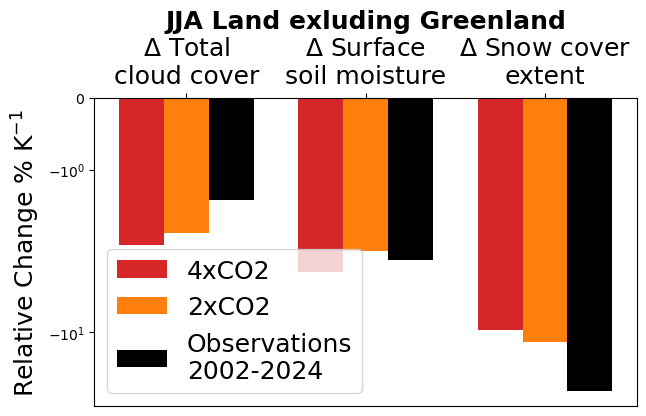

In [111]:
fig, ax = plt.subplots(1, 1, figsize=[7, 4])

vars = ['$\Delta$ Total\ncloud cover', '$\Delta$ Surface\nsoil moisture', '$\Delta$ Snow cover\nextent']
JJA_change = {
    '4xCO2': [ds_cloud_4xCO2_rel['CLDTOT']/ds_4xCO2_abs['TSA'],
              ds_4xCO2_rel['SOILWATER_10CM_corrected']/ds_4xCO2_abs['TSA'],
              ds_4xCO2_rel['FSNO']/ds_4xCO2_abs['TSA']],

    '2xCO2': [ds_cloud_2xCO2_rel['CLDTOT']/ds_2xCO2_abs['TSA'],
              ds_2xCO2_rel['SOILWATER_10CM_corrected']/ds_2xCO2_abs['TSA'],
              ds_2xCO2_rel['FSNO']/ds_2xCO2_abs['TSA']],
    
    'Observations\n2002-2024': [CERES_slope_rel/temp_slope,
                                SM_ERA5_slope_rel/temp_slope,
                                snow_slope_rel/temp_slope],}

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','black']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    multiplier += 1

#ax.set_ylim([-30,0])
ax.set_yscale('symlog')
ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
#ax.set_xticks([-10, -8, -6, -4, 0], [-80, -60, -40, -20, 0], fontsize=18)
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='lower left', fontsize=18)
ax.set_title('JJA Land exluding Greenland',fontsize=18, fontweight='bold')

Text(0.5, 1.0, 'JJA Land exluding Greenland')

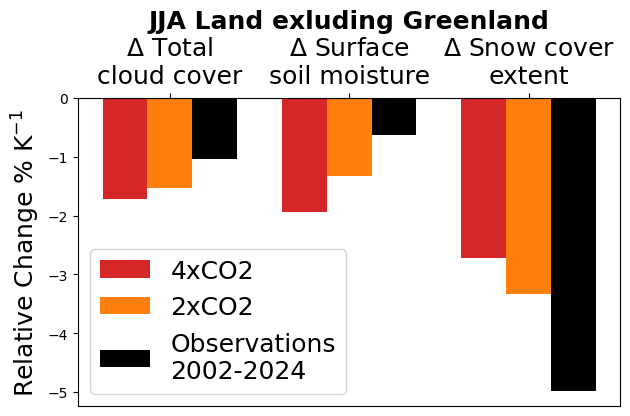

In [110]:
fig, ax = plt.subplots(1, 1, figsize=[7, 4])

vars = ['$\Delta$ Total\ncloud cover', '$\Delta$ Surface\nsoil moisture', '$\Delta$ Snow cover\nextent']
JJA_change = {
    '4xCO2': [ds_cloud_4xCO2_abs['CLDTOT']*100/ds_4xCO2_abs['TSA'],
              ds_4xCO2_abs['SOILWATER_10CM_corrected']/ds_4xCO2_abs['TSA'],
              ds_4xCO2_abs['FSNO']*100/ds_4xCO2_abs['TSA']],

    '2xCO2': [ds_cloud_2xCO2_abs['CLDTOT']*100/ds_2xCO2_abs['TSA'],
              ds_2xCO2_abs['SOILWATER_10CM_corrected']/ds_2xCO2_abs['TSA'],
              ds_2xCO2_abs['FSNO']*100/ds_2xCO2_abs['TSA']],
    
    'Observations\n2002-2024': [CERES_slope/temp_slope,
                                SM_ERA5_slope/temp_slope,
                                snow_slope/temp_slope],}

x = np.arange(len(vars))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
colors = ['tab:red', 'tab:orange','black']
for exp, measurement in JJA_change.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=exp, color=colors[multiplier])
    multiplier += 1

#ax.set_ylim([-30,0])
#ax.set_yscale('symlog')
ax.set_xticks(x + width, vars, fontsize=18)
ax.xaxis.tick_top()
#ax.set_xticks([-10, -8, -6, -4, 0], [-80, -60, -40, -20, 0], fontsize=18)
ax.set_ylabel('Relative Change % K$^{-1}$', fontsize=18)
ax.legend(loc='lower left', fontsize=18)
ax.set_title('JJA Land exluding Greenland',fontsize=18, fontweight='bold')